BG/NGD model:

1.Data Cleaning and Filtering:

Because the massive size of the TaoBao user behaviour dataset (UserBehavior.csv)-3.67 GB and it presents some outliers casued by timestamp overflows, we need to take a chunk-loading strategy. Besides, because of the strategic pivot. we need to extract the actual transaction records where 'behaviour_type == "buy"' and limit the time windows to the official nine-day period (Nov 25,2017-Dec 3, 2017), establishing a rigorous foundation for econimetric time-series analysis.

In [1]:
# import modules
import pandas as pd
import numpy as np

In [2]:
#1.Pre-Clean
#Set column names
column_names = ['user_id', 'item_id', 'category_id','behaviour_type', 'timestamp']

# Set chunk size avoiding OOM
chunk_size = 1000000
buy_records = []

# Set boundary of timestamp in Unix
start_ts = 1511539200 #2017-11-25 00:00:00
end_ts = 1512316800 #2017-12-03 24:00:00

for chunk in pd.read_csv(
    r'../data/UserBehavior.csv',
    header=None,
    names=column_names,
    chunksize=chunk_size
):
# filter: 1. Buying behaviour 2. filter timestamp outliers
    filtered_chunk = chunk[
        (chunk['behaviour_type'] == 'buy') &
        (chunk['timestamp'] >= start_ts) &
        (chunk['timestamp'] <= end_ts)
    ]
    # keep the core metrics
    buy_records.append(filtered_chunk[['user_id','timestamp']])
                       
# combine all transactions
total_transactions = pd.concat(buy_records, axis=0)

# transform timestamp into standard time form
# 1. tansform date into object type
# 2. tansform pre-cleaned date into standard datetime64 type
total_transactions['date'] = pd.to_datetime(total_transactions['timestamp'], unit='s').dt.normalize()

# clean RAM from chunks (buy)records)
del buy_records
print(f' Pre-data clean completed: Including {len(total_transactions)} rows')
print(total_transactions.head(5))

 Pre-data clean completed: Including 2015839 rows
     user_id   timestamp       date
71       100  1511579908 2017-11-25
73       100  1511617549 2017-11-25
100      100  1511759458 2017-11-27
119      100  1511767298 2017-11-27
125      100  1511789940 2017-11-27


2.Sorted by Bhronological Order and Generate RF-T Martix (Parameters for Bayesian posterior):

In this section, we need to aovid data leakage and verify the accuracy of BG/NBD model from different periods. So ,we need to cut the nine days period into 2 test sections (Calibration Period & Holdout Period):
For Calibration Period: we choose the first of six days (From Nov 11, 2017 to Nov 30, 2017) to find the Sufficient Statistics (Recency, Frequency, Customer Age) from users' data to fit the parameters of BG/NBD (Frequency Parameters: r,A; Loss Parameters: a,b).
For Holdout Period: we choose the rest of three days (From Dec 1, 2017 to Dec 3, 2017) to verify if the BG/NBD model is predictable.


In [3]:
# import CLV period training module
from lifetimes.utils import calibration_and_holdout_data

Note: you may need to restart the kernel to use updated packages.


In [4]:
# extract the parameters for bayesian posterior
rft_training = calibration_and_holdout_data(
    total_transactions, # main
    customer_id_col='user_id',
    datetime_col='date',
    calibration_period_end='2017-11-30', # calibration period - 6
    observation_period_end='2017-12-03', # holdout period - 3
    freq='D' # time granularity
)

# test
print(rft_training.head())

         frequency_cal  recency_cal  T_cal  frequency_holdout  \
user_id                                                         
2                  0.0          0.0    2.0                2.0   
4                  1.0          2.0    2.0                0.0   
11                 0.0          0.0    5.0                0.0   
16                 0.0          0.0    0.0                1.0   
24                 0.0          0.0    3.0                0.0   

         duration_holdout  
user_id                    
2                     3.0  
4                     3.0  
11                    3.0  
16                    3.0  
24                    3.0  


3.Probabilistic Baseline Fitting for BG/NBD Model Estimation

We have got the RF-T Martix (Sufficient Statistics: Recency, Frequency, Customer Age/Time) from Pre-cleaned TaoBao dataset. Then, we need to use maximum likelihood estimation (MLE) to fit BG/NBD model to calculate prior parameters (Frequency Parameters: r,A; Loss Parameters: a,b). This is the fundation  of the BG/NBD model.

In [5]:
# 3.1import BetaGeoFitter model from lifetime for priori parameters estimation
from lifetimes import BetaGeoFitter

In [35]:
# 3.2set an initial BG/NBD model
# set a regularization penality term (penalizer_coef=0.0) to aviod overfitting
pp_bg_nbd = BetaGeoFitter(penalizer_coef=0.01)

# start the model's fit method (a numberical optimizer calculator for MLE calculation)
# calculate the best fitting prior parameters: r, alpha, a, b
pp_bg_nbd.fit(
    rft_training['frequency_cal'],
    rft_training['recency_cal'],
    rft_training['T_cal']
)
# print out core prior parameters (Frequency Parameters: r,alpha; Loss Parameters: a,b)
print(pp_bg_nbd.summary)

               coef      se(coef)  lower 95% bound  upper 95% bound
r      1.174419e+00  4.297343e-03     1.165997e+00     1.182842e+00
alpha  5.554068e+00  2.230013e-02     5.510359e+00     5.597776e+00
a      1.745648e-15  2.600584e-12    -5.095400e-12     5.098891e-12
b      7.391932e-06  6.866081e-03    -1.345013e-02     1.346491e-02


In [25]:
# import modules for visulization
import matplotlib.pyplot as plt
from lifetimes.plotting import plot_frequency_recency_matrix
import numpy as np

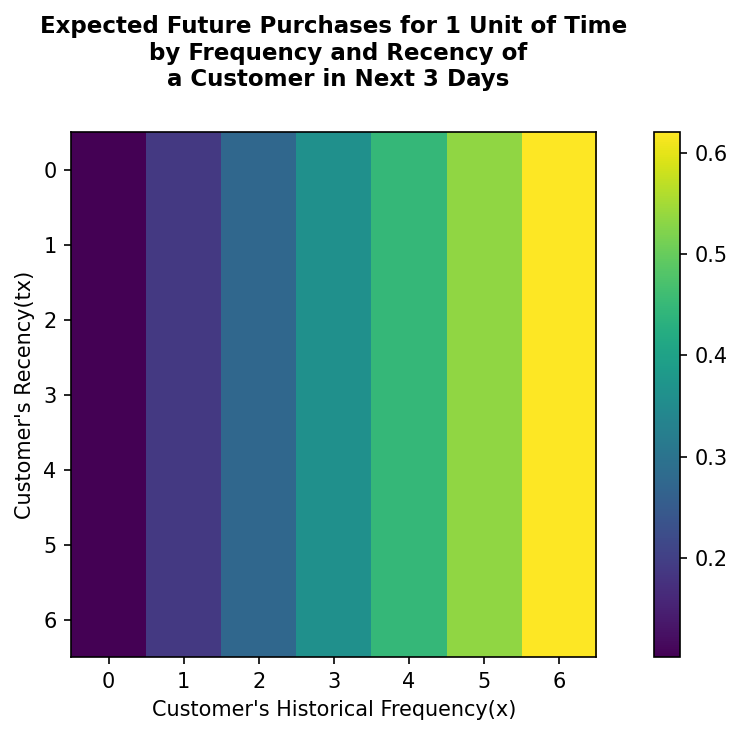

In [24]:
# 3.3 visulization for prediected frequency and recency martix in holdout period
# 3.3.1 RF 2D Martix for prediected frequency and recency (problem!)
plt.figure(figsize=(8,5),dpi=150)
plot_frequency_recency_matrix(pp_bg_nbd)
plt.title('Expected Future Purchases for 1 Unit of Time\n by Frequency and Recency of\n a Customer in Next 3 Days',
          fontsize=11,
          fontweight='bold',
          pad=22)
plt.xlabel("Customer's Historical Frequency(x)", fontsize=10)
plt.ylabel("Customer's Recency(tx)", fontsize=10)
plt.tight_layout()
plt.savefig('figures/NBD/fig1_rf_martix.png', dpi=300, bbox_inches='tight')
plt.show()

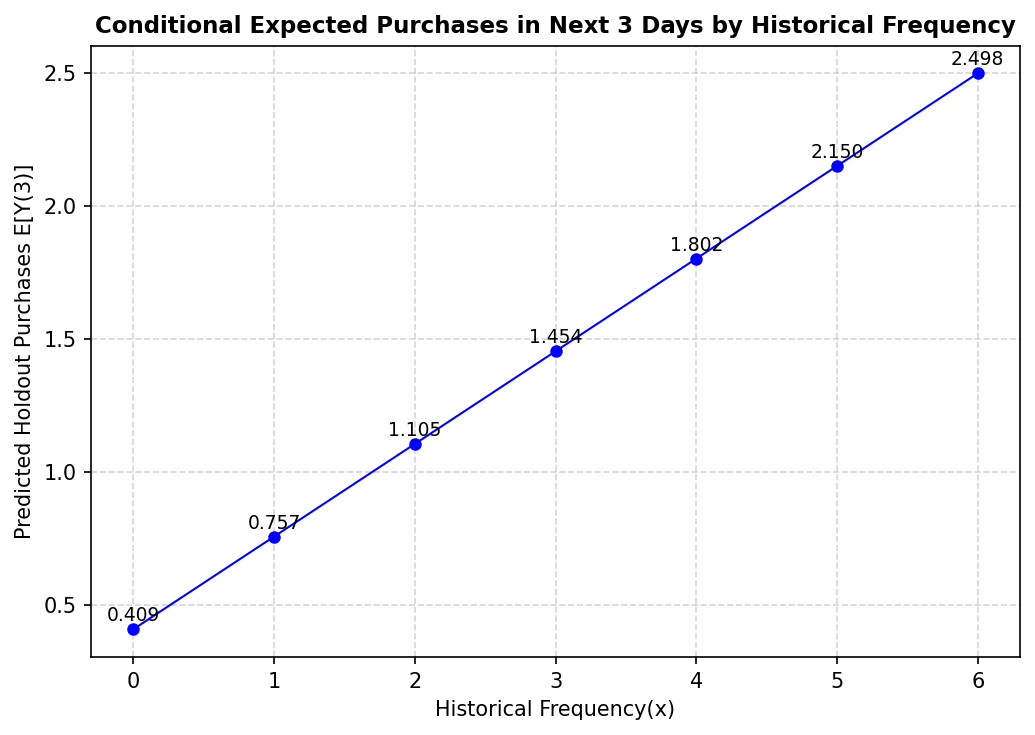

In [33]:
# 3.3.2 1D Expected value line chart for Frequency(x) - predicted recency(tx) no longer work in shor-term promotion
# set historicl frequency as x-axis for calibration period
x_vals = np.arange(0,7)

# extract piror parameters (r, aplha)
r_vals, alpha_vals = pp_bg_nbd.summary.loc['r', 'coef'], pp_bg_nbd.summary.loc['alpha', 'coef']

# calculate mean value of T_cal in database
T_mean = rft_training['T_cal'].mean()

# set predicted period
t_pred = 3

# for every x, take all parameters into formula: (r+x)/(alpha+T_mean)*t_pred for expected value where recency(tx) no longer use/P alive=1
exp_pur = [(r_vals + x) / (alpha_vals + T_mean) * t_pred for x in x_vals]

# draw line chart
plt.figure(figsize=(7,5), dpi=150)
plt.plot(x_vals, exp_pur, marker='o', color='blue', linewidth=1, markersize=5)

# dec into (x,y)
for x, y in zip(x_vals, exp_pur):
    plt.text(x, y +0.015, f'{y:.3f}', ha='center', va='bottom', fontsize=9)
plt.title('Conditional Expected Purchases in Next 3 Days by Historical Frequency', fontsize=11, fontweight='bold')
plt.xlabel("Historical Frequency(x)", fontsize=10)
plt.ylabel("Predicted Holdout Purchases E[Y(3)]", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('figures/NBD/fig2_f_line_chart.png', dpi=300, bbox_inches='tight')
plt.show()

4.Bayesian posterior updating and Individual-level Inference:

We have already calculate core overall user data (recency, frequency, customer age) and prior distribution parameters for entire user data (Frequency Parameters: r,A; Loss Parameters: a,b).

First, we need to take overall user data into a Bayesian posterior upadating to figure out the probability that the user "remains active" by the end of training period.

Second, based on posterior survival probability and purchase rate, calculate the users' predicted number of purchases from conditonal expectation in the next 3 days (E[Y(t)]).

In [7]:
# 4.1 calculate the probability of user "remains active" by Bayesian posterior upadating (P(Active at T/ X = x,tx, T, r, alpha, a, b))
rft_training['prob_user_alive'] = pp_bg_nbd.conditional_probability_alive(
    rft_training['frequency_cal'],
    rft_training['recency_cal'],
    rft_training['T_cal']
)

# calculate the users' future transactions in holdout period (t = 3) by Bayesian posterior updating
t_pred = 3
rft_training['bg_nbd_predicted_purchases'] = pp_bg_nbd.conditional_expected_number_of_purchases_up_to_time(
    t_pred,
    rft_training['frequency_cal'],
    rft_training['recency_cal'],
    rft_training['T_cal']
)

# draw the result out
# save the results for xgboost
rft_training.to_csv('output/bgnbd_features_for_xgboost.csv')

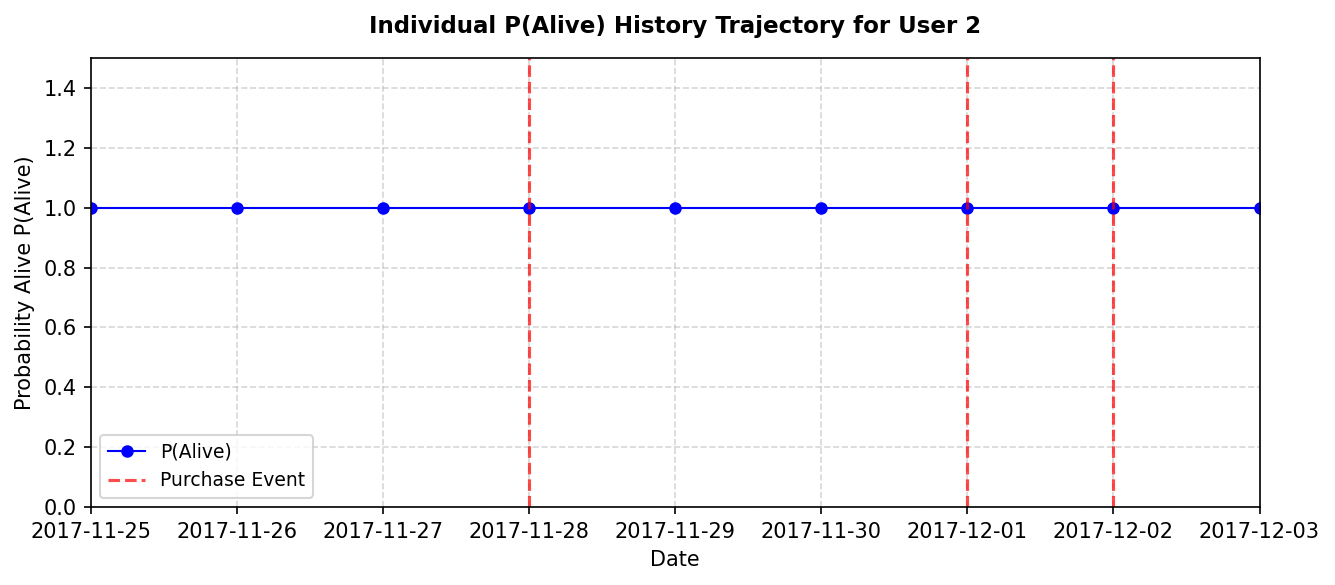

In [62]:
# 4.2 visulization of historicial trajectory for individual probability of customer alive (e.g. user 2)
# 4.2.1 import modules
import matplotlib.pyplot as plt
import pandas as pd
from lifetimes.utils import calculate_alive_path

# choose a random user
target_user_id = 2
user_history = total_transactions[total_transactions['user_id'] == target_user_id][['date']].copy()
user_history['date'] = pd.to_datetime(user_history['date'])

# use liftimes module calculate core metric (probability of user alive)
alive_path = calculate_alive_path(
    model=pp_bg_nbd, 
    transactions=user_history, 
    datetime_col='date', 
    t=9)

# set x-axis start
start_date = pd.Timestamp('2017-11-25')
real_dates = pd.date_range(start=start_date, periods=len(alive_path), freq='D')

# drawing
plt.figure(figsize=(9, 4), dpi=150)

# draw P(Alive) chart line
plt.plot(real_dates, alive_path.values, color='blue', linewidth=1, marker='o', markersize=5, label='P(Alive)')

# label the purchases time points
purchase_dates = user_history['date'].dt.floor('D').unique()
for i, p_date in enumerate(purchase_dates):
    plt.axvline(x=p_date, color='red', linestyle='--', alpha=0.7, 
                label='Purchase Event' if i == 0 else "")  # 避免图例重复展示

# set y and x-axis range
plt.xlim(pd.Timestamp('2017-11-25'), pd.Timestamp('2017-12-03'))
plt.ylim(0, 1.5)

# dec
plt.title(f"Individual P(Alive) History Trajectory for User {target_user_id}", fontsize=11, fontweight='bold', pad=12)
plt.xlabel("Date", fontsize=10)
plt.ylabel("Probability Alive P(Alive)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=9)
plt.tight_layout()

# save
plt.savefig('figures/NBD/fig3_Plive_line_chart.png', dpi=300, bbox_inches='tight')
plt.show()

5.Calculate the MAE (Mean Absolute Error)) and RMSE (Root Mean Square Error) to test the  accuracy of prediction for BG/NBD

Compare the predicted purchases result from BG/NBD with the true purchases in raw data, we could figure out if BG/NBD provide an predictable result.

In [12]:
# 5.1 import MAE and RMSE modules from sklearn
from sklearn.metrics import mean_absolute_error, mean_squared_error

# extract the true values and predictions
true_fre = rft_training['frequency_holdout'] # extract from rft martix
pred_fre = rft_training['bg_nbd_predicted_purchases'] #extract from BG/NBD

# calculate MAE and RMSE
mae = mean_absolute_error(true_fre, pred_fre)
rmse = np.sqrt(mean_squared_error(true_fre, pred_fre))

# print out MAE and RMSE
print(f'MAE:{mae:.4f}')
print(f'RMSE:{rmse:.4f}')

MAE:0.6242
RMSE:0.7363


<Figure size 1200x750 with 0 Axes>

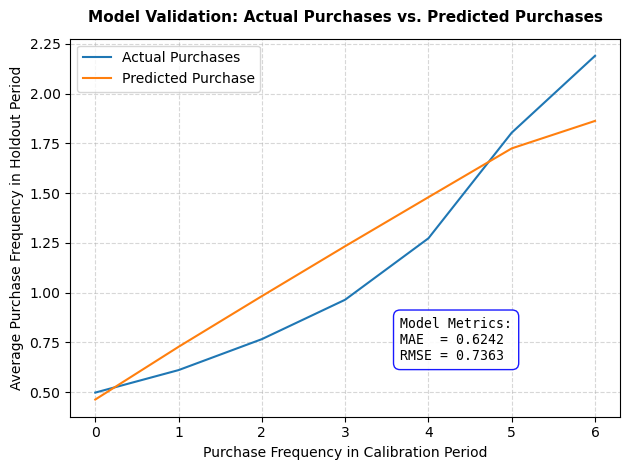

In [70]:
# 5.2 visualization for MAE and RMSE comparation
# import lifetimes.plotting module
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

# set figure
plt.figure(figsize=(8,5), dpi=150)

# set core model from lifetimes
core_model = plot_calibration_purchases_vs_holdout_purchases(
    model=pp_bg_nbd,
    calibration_holdout_matrix=rft_training
)

# use matplotlib to draw
mae_vals = mae
rmse_vals = rmse
plt.text(
    0.60, 0.15,
    f'Model Metrics:\nMAE  = {mae_vals:.4f}\nRMSE = {rmse_vals:.4f}',
    transform=core_model.transAxes,
    fontsize=9.5,
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='blue',alpha=0.9)
)

# dec
plt.title('Model Validation: Actual Purchases vs. Predicted Purchases', fontsize=11, fontweight='bold', pad=12)
plt.xlabel('Purchase Frequency in Calibration Period', fontsize=10)
plt.ylabel('Average Purchase Frequency in Holdout Period', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(['Actual Purchases', 'Predicted Purchase'], loc='upper left', frameon=True)
plt.tight_layout()
plt.savefig('figures/NBD/fig4_MAE_RMSE_chart.png', dpi=300, bbox_inches='tight')
plt.show()